In [1]:
import sys
import os
from pathlib import Path

BASE_DIR = Path().resolve().parents[1]
print(BASE_DIR)

os.chdir(BASE_DIR)

import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import transforms
from DeepLearning.WheatDataset import WheatDataset
from DeepLearning.transformers import make_transforms
from DeepLearning.metrics import evaluate_model
from DeepLearning.loss_functions import BCEDiceLoss, FocalLoss
from DeepLearning.unet.unetModel import UNet
from torchsummary import summary

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

/Users/nawanshaju/Documents/UNSW/26T1/COMP9517/Ass/COMP9517_Project


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


In [2]:
train_tf_aug, val_tf = make_transforms(augment=True)
train_tf_base, _ = make_transforms(augment=False)

/Users/nawanshaju/Documents/UNSW/26T1/COMP9517/Ass/COMP9517_Project/DeepLearning/transformers.py:121: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(


In [3]:
train_ds = WheatDataset('Data/train', transform=train_tf_base)
train_ds_aug = WheatDataset('Data/train', transform=train_tf_aug)
val_ds = WheatDataset('Data/validation', transform=val_tf)
test_ds = WheatDataset('Data/test', transform=val_tf)


In [4]:
train_loader_base = torch.utils.data.DataLoader(train_ds, batch_size=4, shuffle=True)
train_loader_aug = torch.utils.data.DataLoader(train_ds_aug, batch_size=4, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=4, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=4, shuffle=False)

In [5]:
from DeepLearning.metrics import evaluate_model

def train_model(model, train_loader, val_loader, loss_fn, model_name, epochs, optimiser):

    best_iou = 0
    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        model.train()
        epoch_loss = 0

        for images, masks in tqdm(train_loader):

            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, masks)

            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            epoch_loss += loss.item()

        epoch_loss /= len(train_loader)

        val_metrics = evaluate_model(model, val_loader, loss_fn, device)

        total_loss, precision, recall, f1, iou = val_metrics
        
        val_losses.append(total_loss)

        print(f"Epoch {epoch+1}/{epochs}")    
        print(f"Epoch Loss {epoch_loss:.4f}")
        print(f"Loss {total_loss:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1: {f1:.4f}")
        print(f"IoU: {iou:.4f}")

        if iou > best_iou:

            best_iou = iou

            torch.save(model.state_dict(), f"{model_name}.pth")

    return train_losses, val_losses

In [6]:
def visualize_predictions(model, loader, num_samples=3):

    model.eval()
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs)
            preds = (preds > 0.5).float()

            for i in range(num_samples):
                img = images[i].cpu().permute(1,2,0)
                mask = masks[i][0]
                pred = preds[i][0].cpu()

                plt.figure(figsize=(12,4))

                plt.subplot(1,3,1)
                plt.title("Image")
                plt.imshow(img)

                plt.subplot(1,3,2)
                plt.title("Ground Truth")
                plt.imshow(mask, cmap='gray')

                plt.subplot(1,3,3)
                plt.title("Prediction")
                plt.imshow(pred, cmap='gray')

                plt.show()

            break


### Model with Focal Loss

In [9]:
model_with_focal = UNet().to(device)
optimiser = optim.Adam(model_with_focal.parameters(), lr=1e-5)
loss_fn_focal = FocalLoss()

In [ ]:
train_loss_base, val_loss_base = train_model(
    model=model_with_focal, 
    train_loader=train_loader_base, 
    val_loader=val_loader, 
    loss_fn=loss_fn_focal, 
    model_name="unet_base_focal_loss", 
    epochs=10, 
    optimiser=optimiser
)

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(train_loss_base, label="Train loss")
plt.plot(val_loss_base, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss Focal")
plt.title("Training curves")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
model_with_focal.load_state_dict(torch.load("unet_base_focal_loss.pth", map_location=device))

# Evaluate on test data

test_results = evaluate_model(
    model_with_focal,
    test_loader,
    loss_fn_focal,
    device
)

test_loss, precision, recall, f1, iou = test_results

print("BASE MODEL RESULTS\n")

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"IoU: {iou:.4f}")

In [ ]:
visualize_predictions(model_with_focal, test_loader)

In [ ]:
from torchsummary import summary
summary(model_with_focal.to("cpu"), input_size=(3, 350, 350))

# Base Unet Model

In [ ]:
model = UNet().to(device)
optimiser = optim.Adam(model.parameters(), lr=1e-5)
loss_fn = BCEDiceLoss()

In [ ]:
model = model.to(device)


In [ ]:
train_loss_base, val_loss_base = train_model(
    model=model, 
    train_loader=train_loader_base, 
    val_loader=val_loader, 
    loss_fn=loss_fn, 
    model_name="unet_base", 
    epochs=30, 
    optimiser=optimiser
)

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(train_loss_base, label="Train loss")
plt.plot(val_loss_base, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (BCE + Dice)")
plt.title("Training curves")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
model.load_state_dict(torch.load("unet_base.pth", map_location=device))

# Evaluate on test data

test_results = evaluate_model(
    model,
    test_loader,
    loss_fn,
    device
)

test_loss, precision, recall, f1, iou = test_results

print("BASE MODEL RESULTS\n")

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"IoU: {iou:.4f}")

In [ ]:
visualize_predictions(model, test_loader)

# Unet with Data Augmentation

In [ ]:

torch.mps.empty_cache() if torch.backends.mps.is_available() else torch.cuda.empty_cache()

model_aug = UNet().to(device)
optimiser_aug = optim.Adam(model_aug.parameters(), lr=1e-3)
loss_fn_aug = BCEDiceLoss()

train_loss_aug, val_loss_aug = train_model(
    model=model_aug,
    train_loader=train_loader_aug,
    val_loader=val_loader,
    loss_fn=loss_fn_aug,
    model_name="unet_aug",
    epochs=20,
    optimiser=optimiser_aug
)

In [ ]:
model_aug.load_state_dict(torch.load("unet_aug.pth", map_location=device))

# Evaluate on test data

test_results = evaluate_model(
    model_aug,
    test_loader,
    loss_fn,
    device
)

test_loss, precision, recall, f1, iou = test_results

print("BASE MODEL RESULTS\n")

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"IoU: {iou:.4f}")

In [ ]:
visualize_predictions(model_aug, test_loader)

# Unet With Original Image + Data Augmentation

In [7]:
from torch.utils.data import ConcatDataset

train_dataset_combined = ConcatDataset([
    train_ds,
    train_ds_aug
])

In [8]:
train_loader_combined = torch.utils.data.DataLoader(
    train_dataset_combined,
    batch_size=4,
    shuffle=True
)

In [7]:
torch.mps.empty_cache() if torch.backends.mps.is_available() else torch.cuda.empty_cache()

model_comb = UNet().to(device)
optimiser_comb = optim.Adam(model_comb.parameters(), lr=3e-4)
loss_fn_comb = BCEDiceLoss()

In [ ]:
train_loss_aug, val_loss_aug = train_model(
    model=model_comb,
    train_loader=train_loader_combined,
    val_loader=val_loader,
    loss_fn=loss_fn_comb,
    model_name="unet_comb",
    epochs=20,
    optimiser=optimiser_comb
)

100%|██████████| 71/71 [00:46<00:00,  1.54it/s]


Epoch 1/20
Epoch Loss 0.2828
Loss 1.4990
Precision: 0.9694
Recall: 0.8848
F1: 0.9246
IoU: 0.8608


100%|██████████| 71/71 [00:44<00:00,  1.58it/s]


Epoch 2/20
Epoch Loss 0.2069
Loss 1.0550
Precision: 0.9254
Recall: 0.9607
F1: 0.9420
IoU: 0.8909


100%|██████████| 71/71 [00:44<00:00,  1.58it/s]


...

Epoch 18/20
Epoch Loss 0.1219
Loss 0.7085
Precision: 0.9687
Recall: 0.9376
F1: 0.9527
IoU: 0.9100


100%|██████████| 71/71 [00:44<00:00,  1.61it/s]


Epoch 19/20
Epoch Loss 0.1279
Loss 0.8445
Precision: 0.9605
Recall: 0.9148
F1: 0.9360
IoU: 0.8806


100%|██████████| 71/71 [00:44<00:00,  1.61it/s]


Epoch 20/20
Epoch Loss 0.1354
Loss 0.7018
Precision: 0.9549
Recall: 0.9517
F1: 0.9532
IoU: 0.9110


In [8]:
model_comb.load_state_dict(torch.load("unet_comb.pth", map_location=device))

# Evaluate on test data

test_results = evaluate_model(
    model_comb,
    test_loader,
    loss_fn_comb,
    device
)

test_loss, precision, recall, f1, iou = test_results

print("BASE MODEL RESULTS\n")

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"IoU: {iou:.4f}")

BASE MODEL RESULTS

Precision: 0.9522
Recall: 0.9419
F1-score: 0.9469
IoU: 0.8993


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285712].


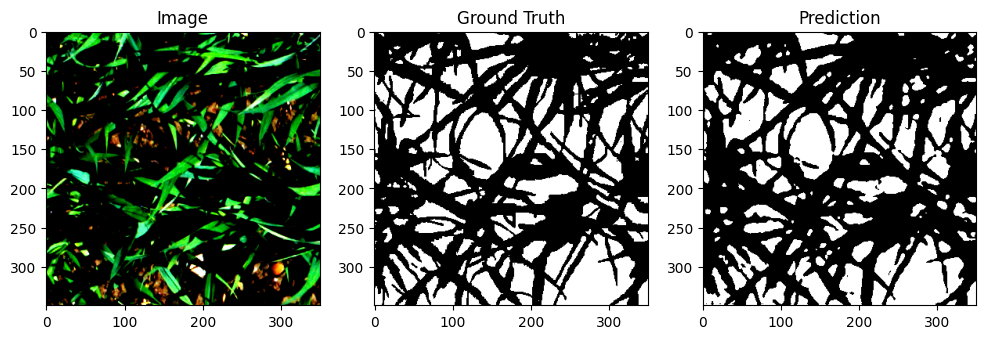

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5702832].


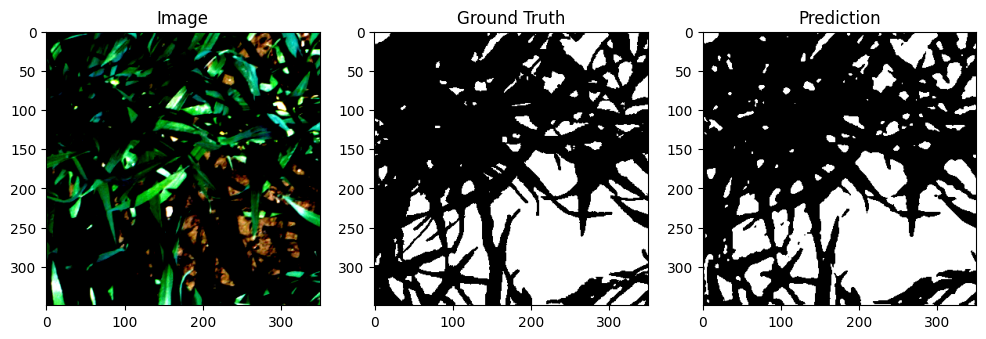

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..2.6399999].


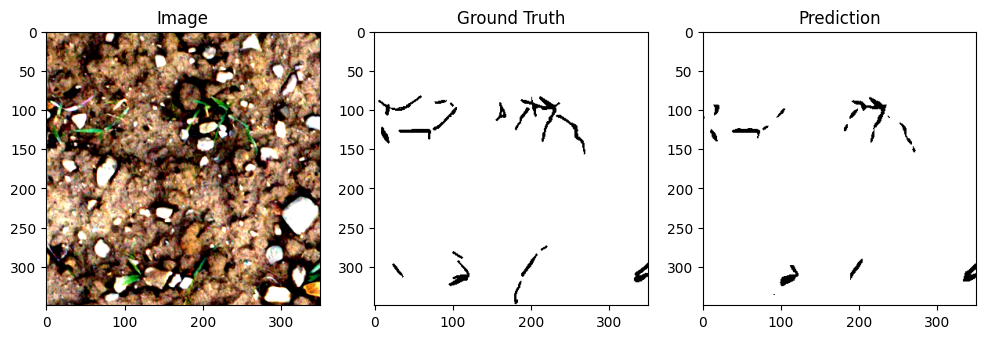

In [9]:
visualize_predictions(model_comb, test_loader)

## Testing with augmented test data

In [10]:
test_dataset_aug = WheatDataset('Data/train', transform=train_tf_aug)
test_loader_aug = torch.utils.data.DataLoader(test_dataset_aug, batch_size=4, shuffle=False)

In [11]:
print("BASE MODEL → AUGMENTED TEST")

base_aug_results = evaluate_model(
    model,
    test_loader_aug,
    loss_fn,
    device
)

print("\nBase Model on Augmented Test:")

print(f"Precision: {base_aug_results[1]:.4f}")
print(f"Recall: {base_aug_results[2]:.4f}")
print(f"F1-score: {base_aug_results[3]:.4f}")
print(f"IoU: {base_aug_results[4]:.4f}")

BASE MODEL → AUGMENTED TEST


NameError: name 'model' is not defined

In [ ]:
print("BASE MODEL → Normal TEST")

base_aug_results = evaluate_model(
    model,
    test_loader,
    loss_fn,
    device
)

print("\nBase Model on Augmented Test:")

print(f"Precision: {base_aug_results[1]:.4f}")
print(f"Recall: {base_aug_results[2]:.4f}")
print(f"F1-score: {base_aug_results[3]:.4f}")
print(f"IoU: {base_aug_results[4]:.4f}")

In [14]:
print("\nAUGMENTED MODEL → AUGMENTED TEST")

aug_aug_results = evaluate_model(
    model_aug,
    test_loader_aug,
    loss_fn_aug,
    device
)

print("\nAugmented Model on Augmented Test:")

print(f"Precision: {aug_aug_results[1]:.4f}")
print(f"Recall: {aug_aug_results[2]:.4f}")
print(f"F1-score: {aug_aug_results[3]:.4f}")
print(f"IoU: {aug_aug_results[4]:.4f}")


AUGMENTED MODEL → AUGMENTED TEST


NameError: name 'model_aug' is not defined

In [ ]:
print("\nAUGMENTED MODEL → Normal TEST")

aug_normal_results = evaluate_model(
    model_aug,
    test_loader,
    loss_fn_aug,
    device
)

print("\nAugmented Model on Augmented Test:")

print(f"Precision: {aug_aug_results[1]:.4f}")
print(f"Recall: {aug_aug_results[2]:.4f}")
print(f"F1-score: {aug_aug_results[3]:.4f}")
print(f"IoU: {aug_aug_results[4]:.4f}")

In [12]:
print("\nCOMBINED MODEL → AUGMENTED TEST")

comb_aug_results = evaluate_model(
    model_comb,
    test_loader_aug,
    loss_fn_comb,
    device
)

print("\nAugmented Model on Augmented Test:")

print(f"Precision: {comb_aug_results[1]:.4f}")
print(f"Recall: {comb_aug_results[2]:.4f}")
print(f"F1-score: {comb_aug_results[3]:.4f}")
print(f"IoU: {comb_aug_results[4]:.4f}")


COMBINED MODEL → AUGMENTED TEST

Augmented Model on Augmented Test:
Precision: 0.9179
Recall: 0.9825
F1-score: 0.9486
IoU: 0.9035


In [13]:
print("\nCOMBINED MODEL → Normal TEST")

comb_normal_results = evaluate_model(
    model_comb,
    test_loader,
    loss_fn_comb,
    device
)

print("\nAugmented Model on Augmented Test:")

print(f"Precision: {comb_aug_results[1]:.4f}")
print(f"Recall: {comb_aug_results[2]:.4f}")
print(f"F1-score: {comb_aug_results[3]:.4f}")
print(f"IoU: {comb_aug_results[4]:.4f}")


COMBINED MODEL → Normal TEST

Augmented Model on Augmented Test:
Precision: 0.9179
Recall: 0.9825
F1-score: 0.9486
IoU: 0.9035


In [14]:
DISPLAY_INDICES = [0, 11, 20]

imgs_list  = []
masks_list = []
for idx in DISPLAY_INDICES:
    img, mask = test_loader_aug.dataset[idx]
    imgs_list.append(img)
    masks_list.append(mask)

fixed_loader = [(torch.stack(imgs_list), torch.stack(masks_list))]

In [ ]:
print("Base Model Predictions on Augmented Test\n\n")

visualize_predictions(
    model,
    fixed_loader,
)

print("Augmented Model Predictions on Augmented Test\n\n")

visualize_predictions(
    model_aug,
    fixed_loader,
)

Combined Model Predictions on Augmented Test




Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877123].


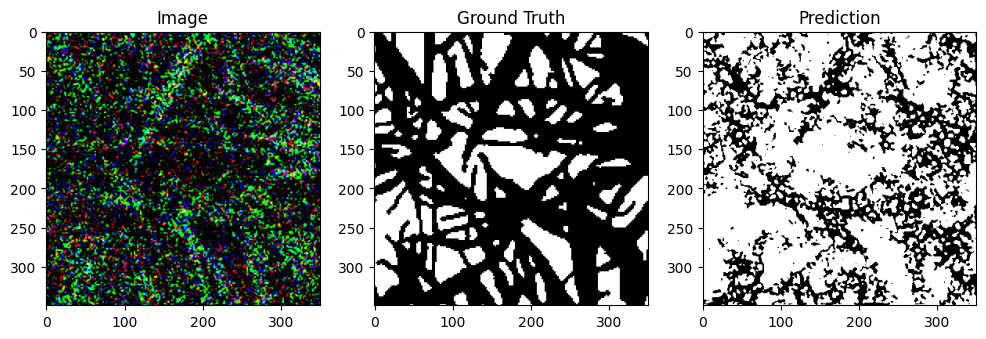

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3644148..2.0299783].


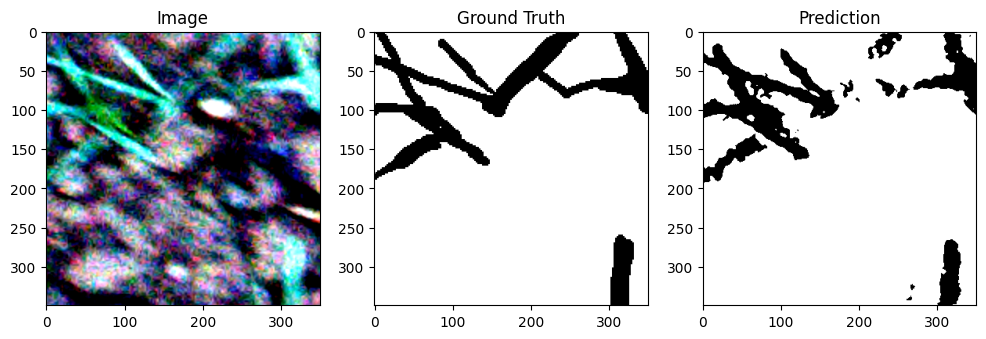

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


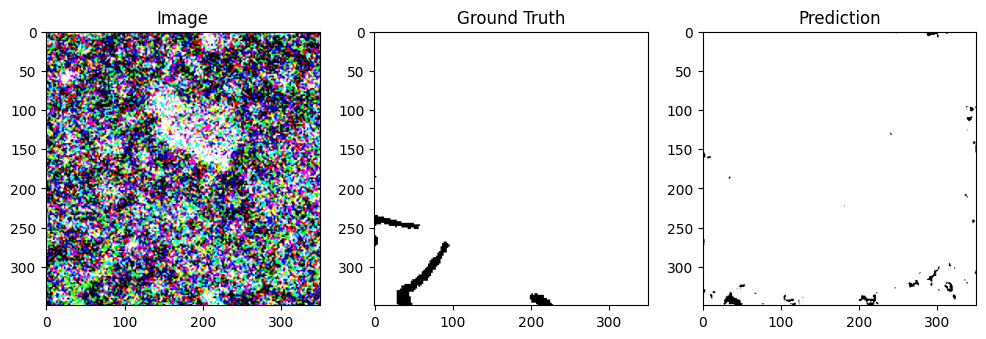

In [15]:
print("Combined Model Predictions on Augmented Test\n\n")

visualize_predictions(
    model_comb,
    fixed_loader,
)

In [ ]:
DISPLAY_INDICES = [0, 10, 20]

imgs_list  = []
masks_list = []
for idx in DISPLAY_INDICES:
    img, mask = test_loader_aug.dataset[idx]
    imgs_list.append(img)
    masks_list.append(mask)

fixed_loader = [(torch.stack(imgs_list), torch.stack(masks_list))]

In [ ]:
model = UNet().to(device)
model_aug = UNet().to(device)
model_comb = UNet().to(device)

model.load_state_dict(torch.load("unet_base.pth", map_location=device))
model_aug.load_state_dict(torch.load("unet_aug.pth", map_location=device))
model_comb.load_state_dict(torch.load("unet_comb.pth", map_location=device))

In [ ]:
visualize_predictions(
    model_comb,
    fixed_loader,
)